# Notebook 8: Distribution Analysis

## Overview

This notebook analyzes the probability distributions of key numerical features in the customer dataset.

The analysis focuses on:

- Understanding the shape of numerical distributions
- Comparing Normal and Uniform distributions
- Measuring central tendency using Mean and Median
- Measuring spread using Standard Deviation and IQR
- Understanding symmetry and skewness
- Understanding kurtosis
- Identifying possible outliers
- Visualizing distributions using Histograms and KDE plots

The numerical features selected for this analysis are:

- Age
- MonthlyCharges
- TenureYears

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load the Dataset

The customer dataset is stored in the CSV file `custumer.csv`.

We use Pandas `read_csv()` to load the dataset into a DataFrame.

In [2]:
# Load dataset
df = pd.read_csv("custumer.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (5020, 14)


,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.10,2394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.50,3796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


## 3. Check the Dataset

Before performing distribution analysis, it is useful to check:

- Column names
- Data types
- Missing values
- Basic statistical information

This helps ensure that the selected numerical features are suitable for analysis.

In [4]:
# Display column names
print("Columns in the dataset:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns in the dataset:
['CustomerID', 'Age', 'Gender', 'TenureYears', 'MonthlyCharges', 'TotalCharges', 'ContractType', 'InternetService', 'PaymentMethod', 'SeniorCitizen', 'SupportCalls', 'StreamingService', 'PaperlessBilling', 'Churn']

Data types:
CustomerID           object
Age                 float64
Gender               object
TenureYears           int64
MonthlyCharges      float64
TotalCharges        float64
ContractType         object
InternetService      object
PaymentMethod        object
SeniorCitizen        object
SupportCalls          int64
StreamingService     object
PaperlessBilling     object
Churn                object
dtype: object


In [5]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
CustomerID           0
Age                 51
Gender               0
TenureYears          0
MonthlyCharges      50
TotalCharges        51
ContractType         0
InternetService      0
PaymentMethod        0
SeniorCitizen        0
SupportCalls         0
StreamingService     0
PaperlessBilling     0
Churn                0
dtype: int64


In [6]:
# Display descriptive statistics
df.describe().round(2)

,Age,TenureYears,MonthlyCharges,TotalCharges,SupportCalls
count,4969.00,5020.00,4970.00,4969.00,5020.00
mean,43.33,4.91,69.48,4126.25,2.11
std,14.76,3.14,28.68,3237.10,1.63
min,18.00,0.00,20.02,72.45,0.00
25%,31.00,2.00,44.60,1440.88,1.00
50%,43.00,5.00,69.28,3355.92,2.00
75%,56.00,8.00,93.77,6068.80,3.00
max,69.00,10.00,119.97,14603.30,9.00


## 4. Theoretical Concepts Overview

### Normal Distribution

A Normal Distribution is a bell-shaped and approximately symmetric distribution.

In a perfectly normal distribution:

- Mean ≈ Median ≈ Mode
- Most observations are concentrated around the center
- The two sides have similar shapes
- The tails gradually decrease toward both ends

### Uniform Distribution

A Uniform Distribution is a distribution where values occur with approximately equal frequency across a particular range.

The histogram of a uniform distribution usually appears relatively flat.

### Symmetric Distribution

A distribution is symmetric when the left and right sides have approximately similar shapes.

For a symmetric distribution:

**Mean ≈ Median**

### Right-Skewed Distribution

A right-skewed distribution has a longer tail toward larger values.

It is also called **positive skewness**.

Usually:

**Mean > Median**

### Left-Skewed Distribution

A left-skewed distribution has a longer tail toward smaller values.

It is also called **negative skewness**.

Usually:

**Mean < Median**

### Skewness

Skewness measures the asymmetry of a distribution.

- Skewness ≈ 0 → approximately symmetric
- Positive skewness → right-skewed
- Negative skewness → left-skewed

### Kurtosis

Kurtosis describes the tail behavior of a distribution compared with a normal distribution.

Using Pandas' `kurtosis()` method:

- Kurtosis ≈ 0 → similar tail behavior to normal distribution
- Kurtosis > 0 → heavier tails / more extreme values
- Kurtosis < 0 → lighter tails / flatter distribution

### Interquartile Range (IQR)

IQR measures the spread of the middle 50% of observations.

**IQR = Q3 - Q1**

where:

- Q1 = 25th percentile
- Q3 = 75th percentile

## 5. Select Key Numerical Features

For this distribution analysis, we focus on:

- **Age** – customer age
- **MonthlyCharges** – monthly amount charged to the customer
- **TenureYears** – number of years the customer has stayed with the company

These variables are numerical and are suitable for distribution analysis.

In [8]:
num_cols = ["Age", "MonthlyCharges", "TenureYears"]

# Check that the selected columns exist
print("Selected numerical features:")
print(num_cols)

df[num_cols].head()

Selected numerical features:
['Age', 'MonthlyCharges', 'TenureYears']


,Age,MonthlyCharges,TenureYears
0,56.0,20.41,0
1,69.0,21.10,9
2,46.0,61.66,3
3,32.0,35.50,8
4,60.0,86.45,9


## 6. Calculate Distribution Metrics

The following metrics are calculated for each numerical feature:

### Mean
The average value of the observations.

### Median
The middle value when the observations are arranged in order.

### Standard Deviation
Measures how far observations typically vary from the mean.

### IQR
Measures the spread of the middle 50% of observations.

### Skewness
Measures the asymmetry of the distribution.

### Kurtosis
Measures tail behavior and peakedness relative to a normal distribution.

Comparing these metrics helps us understand the overall distribution of each feature.

In [9]:
dist_metrics = pd.DataFrame(
    index=[
        "Mean (Center)",
        "Median (Center)",
        "Std Dev (Spread)",
        "IQR (Spread)",
        "Skewness",
        "Kurtosis",
    ]
)

for col in num_cols:
    series = df[col].dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    
    dist_metrics[col] = [
        series.mean(),
        series.median(),
        series.std(),
        q3 - q1,
        series.skew(),
        series.kurtosis(),
    ]

dist_metrics.round(2)

,Age,MonthlyCharges,TenureYears
Mean (Center),43.33,69.48,4.91
Median (Center),43.00,69.28,5.00
Std Dev (Spread),14.76,28.68,3.14
IQR (Spread),25.00,49.17,6.00
Skewness,0.01,0.04,0.03
Kurtosis,-1.21,-1.18,-1.21


## 7. Mean vs Median

Mean and Median are important measures of central tendency.

Their relationship provides an initial indication of the distribution's symmetry.

- Mean ≈ Median → approximately symmetric
- Mean > Median → possible right skew
- Mean < Median → possible left skew

However, skewness should also be considered before making a final conclusion.

In [10]:
center_comparison = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median()
})

center_comparison.round(2)

,Mean,Median
Age,43.33,43.00
MonthlyCharges,69.48,69.28
TenureYears,4.91,5.00


## 8. Visualizing Feature Distributions

Histograms are useful for understanding the shape and spread of numerical data.

A KDE (Kernel Density Estimate) curve is added to the histogram to provide a smooth representation of the distribution.

The plots help us identify:

- Normal-like patterns
- Uniform-like patterns
- Skewness
- Multiple peaks
- Concentration of observations
- Possible extreme values

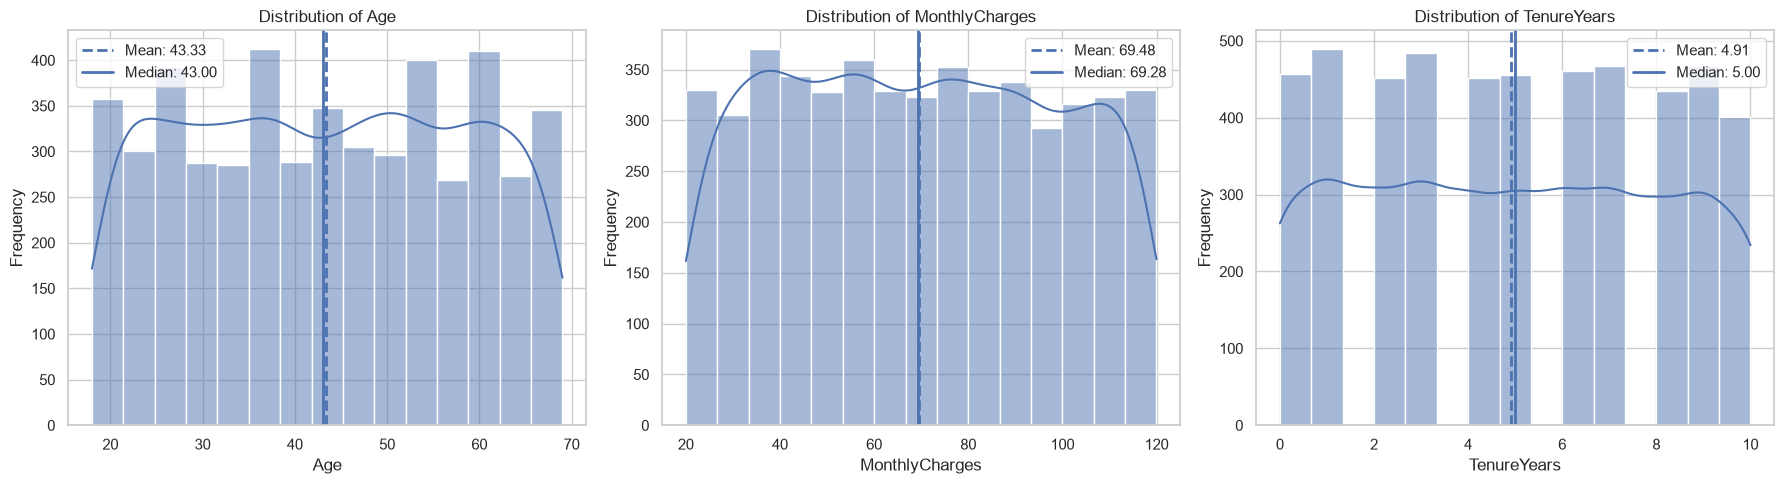

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col].dropna(),
        kde=True,
        ax=axes[i],
        bins=15
    )
    
    mean_value = df[col].mean()
    median_value = df[col].median()
    
    axes[i].axvline(
        mean_value,
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_value:.2f}"
    )
    
    axes[i].axvline(
        median_value,
        linestyle="-",
        linewidth=2,
        label=f"Median: {median_value:.2f}"
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

plt.tight_layout()
plt.show()

## 9. Box Plot Analysis

Box plots provide a compact view of:

- Median
- First quartile (Q1)
- Third quartile (Q3)
- Interquartile Range (IQR)
- Potential outliers

Potential outliers are generally shown as individual points outside the whiskers.

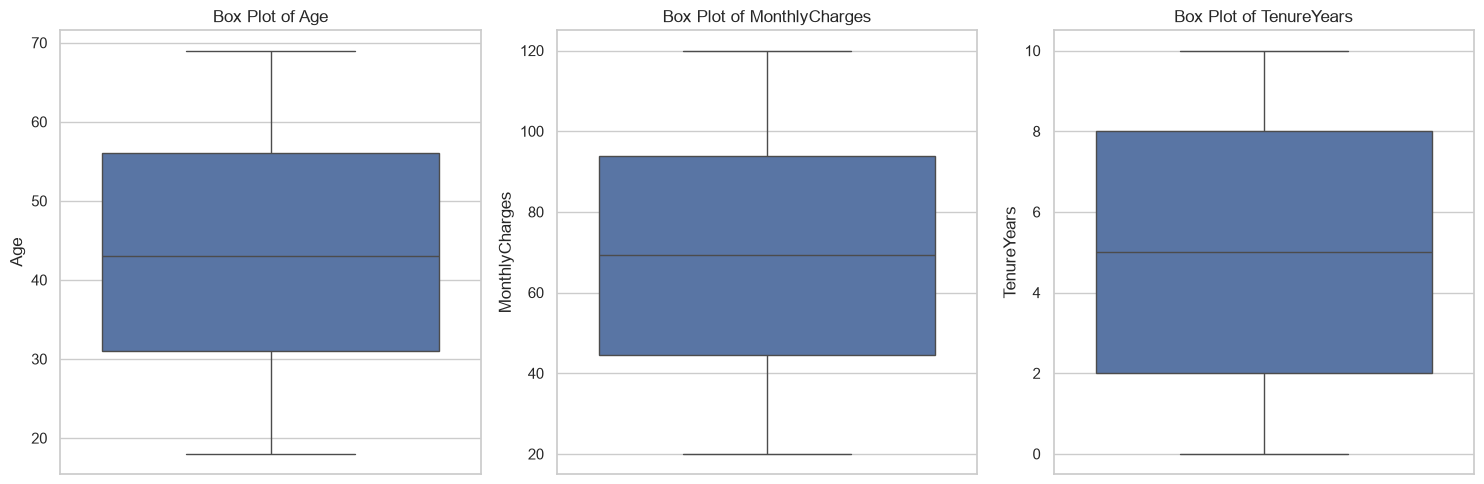

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(
        y=df[col].dropna(),
        ax=axes[i]
    )
    
    axes[i].set_title(f"Box Plot of {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 10. Detect Potential Outliers Using IQR

The Interquartile Range method can be used to identify potential outliers.

The lower and upper boundaries are calculated as:

**Lower Bound = Q1 - 1.5 × IQR**

**Upper Bound = Q3 + 1.5 × IQR**

Values below the lower bound or above the upper bound are considered potential outliers.

This method does not automatically mean that these observations are errors. They should be investigated before removing or modifying them.

In [14]:
outlier_summary = []

for col in num_cols:
    series = df[col].dropna()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = series[
        (series < lower_bound) | (series > upper_bound)
    ]
    
    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.round(2)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,31.0,56.00,25.00,-6.50,93.50,0
1,MonthlyCharges,44.6,93.77,49.17,-29.15,167.52,0
2,TenureYears,2.0,8.00,6.00,-7.00,17.00,0


## 11. Interpret Skewness

A simple interpretation of skewness is:

- Between -0.5 and 0.5 → approximately symmetric
- Between -1 and -0.5 or 0.5 and 1 → moderately skewed
- Less than -1 or greater than 1 → highly skewed

These are practical guidelines rather than strict statistical rules.

The actual value should be considered together with the histogram and KDE plot.

In [15]:
skewness_values = df[num_cols].skew()

skewness_table = pd.DataFrame({
    "Skewness": skewness_values
})

def interpret_skewness(value):
    if -0.5 <= value <= 0.5:
        return "Approximately Symmetric"
    elif 0.5 < value <= 1:
        return "Moderately Right-Skewed"
    elif value > 1:
        return "Highly Right-Skewed"
    elif -1 <= value < -0.5:
        return "Moderately Left-Skewed"
    else:
        return "Highly Left-Skewed"

skewness_table["Interpretation"] = skewness_table["Skewness"].apply(
    interpret_skewness
)

skewness_table.round(2)

,Skewness,Interpretation
Age,0.01,Approximately Symmetric
MonthlyCharges,0.04,Approximately Symmetric
TenureYears,0.03,Approximately Symmetric


## 12. Interpret Kurtosis

Pandas returns **excess kurtosis**.

Therefore:

- Kurtosis close to 0 → similar to a normal distribution
- Positive kurtosis → relatively heavier tails
- Negative kurtosis → relatively lighter tails and flatter shape

Kurtosis should not be interpreted alone. It is useful to combine it with the histogram and other distribution metrics.

In [17]:
kurtosis_table = pd.DataFrame({
    "Kurtosis": df[num_cols].kurtosis()
})

def interpret_kurtosis(value):
    if value > 0.5:
        return "Relatively Heavy-Tailed"
    elif value < -0.5:
        return "Relatively Flat / Light-Tailed"
    else:
        return "Close to Normal Tail Behavior"

kurtosis_table["Interpretation"] = kurtosis_table["Kurtosis"].apply(
    interpret_kurtosis
)

kurtosis_table.round(2)

,Kurtosis,Interpretation
Age,-1.21,Relatively Flat / Light-Tailed
MonthlyCharges,-1.18,Relatively Flat / Light-Tailed
TenureYears,-1.21,Relatively Flat / Light-Tailed


## 13. Detailed Distribution Summary

The following table combines the main distribution characteristics of the selected numerical variables.

The interpretation is based on:

- Histogram shape
- Mean and Median
- Standard Deviation
- IQR
- Skewness
- Kurtosis
- IQR-based potential outlier detection

The values are calculated directly from the dataset, so the summary will remain consistent even if the dataset values differ from an example.

In [19]:
summary_rows = []

for col in num_cols:
    series = df[col].dropna()
    
    mean_value = series.mean()
    median_value = series.median()
    std_value = series.std()
    skew_value = series.skew()
    kurt_value = series.kurtosis()
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = (
        (series < lower_bound) | (series > upper_bound)
    ).sum()
    
    if abs(skew_value) <= 0.5:
        shape = "Approximately Symmetric"
    elif skew_value > 0.5:
        shape = "Right-Skewed"
    else:
        shape = "Left-Skewed"
    
    if kurt_value > 0.5:
        kurtosis_interpretation = "Heavy-Tailed"
    elif kurt_value < -0.5:
        kurtosis_interpretation = "Flat / Light-Tailed"
    else:
        kurtosis_interpretation = "Near Normal"
    
    if outlier_count == 0:
        outlier_status = "No potential outliers"
    else:
        outlier_status = f"{outlier_count} potential outlier(s)"
    
    summary_rows.append({
        "Variable": col,
        "Shape": shape,
        "Mean": mean_value,
        "Median": median_value,
        "Std Dev": std_value,
        "IQR": iqr,
        "Skewness": skew_value,
        "Kurtosis": kurt_value,
        "Outlier Status": outlier_status
    })

distribution_summary = pd.DataFrame(summary_rows)

distribution_summary.round(2)

,Variable,Shape,Mean,Median,Std Dev,IQR,Skewness,Kurtosis,Outlier Status
0,Age,Approximately Symmetric,43.33,43.00,14.76,25.00,0.01,-1.21,No potential outliers
1,MonthlyCharges,Approximately Symmetric,69.48,69.28,28.68,49.17,0.04,-1.18,No potential outliers
2,TenureYears,Approximately Symmetric,4.91,5.00,3.14,6.00,0.03,-1.21,No potential outliers


## 14. Distribution Interpretation

The following code generates a simple interpretation for each numerical feature.

This provides a data-driven explanation rather than manually entering values from an example.

In [20]:
for col in num_cols:
    series = df[col].dropna()
    
    mean_value = series.mean()
    median_value = series.median()
    skew_value = series.skew()
    kurt_value = series.kurtosis()
    
    print("=" * 60)
    print(f"Feature: {col}")
    print("=" * 60)
    
    print(f"Mean: {mean_value:.2f}")
    print(f"Median: {median_value:.2f}")
    print(f"Skewness: {skew_value:.2f}")
    print(f"Kurtosis: {kurt_value:.2f}")
    
    if abs(skew_value) <= 0.5:
        print("Shape: Approximately symmetric.")
    elif skew_value > 0:
        print("Shape: Right-skewed.")
    else:
        print("Shape: Left-skewed.")
    
    if kurt_value > 0.5:
        print("Kurtosis: Relatively heavy-tailed.")
    elif kurt_value < -0.5:
        print("Kurtosis: Relatively flat/light-tailed.")
    else:
        print("Kurtosis: Close to normal tail behavior.")
    
    print()

Feature: Age
Mean: 43.33
Median: 43.00
Skewness: 0.01
Kurtosis: -1.21
Shape: Approximately symmetric.
Kurtosis: Relatively flat/light-tailed.

Feature: MonthlyCharges
Mean: 69.48
Median: 69.28
Skewness: 0.04
Kurtosis: -1.18
Shape: Approximately symmetric.
Kurtosis: Relatively flat/light-tailed.

Feature: TenureYears
Mean: 4.91
Median: 5.00
Skewness: 0.03
Kurtosis: -1.21
Shape: Approximately symmetric.
Kurtosis: Relatively flat/light-tailed.

